<a href="https://colab.research.google.com/github/d-anjos/Daniela_Anjos_Desafio_IA/blob/main/Daniela_Anjos_desafio_extra_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**DESAFIO EXTRA – PREVISÃO DE CANCELAMENTO DE RESERVAS DE HOTEL**

**Curso**: Introdução à Inteligência Artificial (Carreira Tech SCTEC)

**Autora**: Daniela dos Anjos

**Dataset**: Hotel Booking Demand (Kaggle) (https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

**Objetivo**: Prever se uma reserva será cancelada (is_canceled = 1)


## **1. IMPORTAÇÃO DAS BIBLIOTECAS**

In [73]:
# 1. IMPORTAÇÃO DAS BIBLIOTECAS (conforme aulas: pandas, numpy, matplotlib, seaborn, sklearn)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [74]:
# Configurações de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


## **2. CARREGAMENTO E COMPREENSÃO DOS DADOS**
### **2.1 Leitura do arquivo**

In [75]:
# Importando o dataset
# Baixar o dataset "SampleSuperstore.csv" no Kaglle https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
from google.colab import files
import io

# Clique no botão 'Escolher arquivos' abaixo e selecione o arquivo 'hotel_bookings.csv' do seu computador.
uploaded = files.upload()

# Carrega o arquivo que foi feito upload e o lê como um DataFrame do Pandas, usando 'latin-1' como codificação para evitar erros de caracteres.
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='latin-1')

Saving hotel_bookings.csv to hotel_bookings.csv


In [76]:
# Pode também ser carregado da seguinte forma:
# import kagglehub
# data = pd.read_csv('/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv')

# Carrega o arquivo que foi feito upload e o lê como um DataFrame do Pandas, usando 'latin-1' como codificação para evitar erros de caracteres.
# filename = list(uploaded.keys())[0]
# df = pd.read_csv('hotel_bookings.csv', encoding='latin-1')


### **2.2 Exploração inicial da estrutura**

In [77]:
# Exibe um resumo conciso do DataFrame, incluindo o número de entradas, colunas, tipos de dados de cada coluna, e a contagem de valores não nulos, o que é essencial para identificar dados ausentes e verificar os tipos de dados.
df.info() # mostra tipos de dados.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [78]:
print("\n--- Dataset carregado ---")
print(f"Shape: {df.shape[0]} linhas e {df.shape[1]} colunas")
print("\nPrimeiras 5 linhas:")
print(df.head())
print("\nInformações gerais:")
df.info()


--- Dataset carregado ---
Shape: 119390 linhas e 32 colunas

Primeiras 5 linhas:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0  

In [79]:
# Exibe o número de linhas e colunas (formato: (linhas, colunas)) do DataFrame, fornecendo uma visão geral do seu tamanho.
df.shape

(119390, 32)

In [80]:
# Exibe as primeiras 5 linhas do DataFrame `df`, o que é útil para uma rápida visualização dos dados e da sua estrutura.
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [81]:
# Exibe as últimas 5 linhas do DataFrame `df`, o que ajuda a verificar a integridade dos dados no final do conjunto.
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [82]:
# Gera estatísticas descritivas (contagem, média, desvio padrão, mínimo, quartis e máximo) para as colunas numéricas do DataFrame, fornecendo um resumo rápido dos dados.
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [83]:
# Conta a frequência de cada valor único na coluna 'country' (país), mostrando a distribuição dos países de origem dos hóspedes.
df['country'].value_counts()

,count
country,
PRT,48590
GBR,12129
FRA,10415
ESP,8568
DEU,7287
...,...
MRT,1
KIR,1
SDN,1


In [84]:
# Conta a frequência de cada valor único na coluna 'company' (empresa), indicando a distribuição das empresas associadas às reservas.
df['company'].value_counts()

,count
company,
40.0,927
223.0,784
67.0,267
45.0,250
153.0,215
...,...
18.0,1
273.0,1
368.0,1


In [85]:
# Conta a frequência de cada valor único na coluna 'agent' (agente), indicando a distribuição dos agentes associados às reservas.
df['agent'].value_counts()

,count
agent,
9.0,31961
240.0,13922
1.0,7191
14.0,3640
7.0,3539
...,...
197.0,1
294.0,1
388.0,1


In [86]:
# Conta o número de valores únicos em cada coluna do DataFrame `df`, o que ajuda a entender a cardinalidade de cada recurso.
df.nunique()

,0
hotel,2
is_canceled,2
lead_time,479
arrival_date_year,3
arrival_date_month,12
arrival_date_week_number,53
arrival_date_day_of_month,31
stays_in_weekend_nights,17
stays_in_week_nights,35
adults,14


In [87]:
# Conta a frequência de cada valor único na coluna 'hotel', indicando a distribuição de reservas entre diferentes tipos de hotéis.
df['hotel'].value_counts()

,count
hotel,
City Hotel,79330
Resort Hotel,40060


In [88]:
# Conta a frequência de cada valor único na coluna 'babies', indicando a distribuição do número de bebês por reserva.
df['babies'].value_counts()

,count
babies,
0,118473
1,900
2,15
10,1
9,1


In [89]:
# Conta a frequência de cada valor único na coluna 'market_segment', mostrando a distribuição dos segmentos de mercado das reservas.
df['market_segment'].value_counts()

,count
market_segment,
Online TA,56477
Offline TA/TO,24219
Groups,19811
Direct,12606
Corporate,5295
Complementary,743
Aviation,237
Undefined,2


In [90]:
# Conta a frequência de cada valor único na coluna 'distribution_channel', mostrando como as reservas foram distribuídas.
df['distribution_channel'].value_counts()

,count
distribution_channel,
TA/TO,97870
Direct,14645
Corporate,6677
GDS,193
Undefined,5


## **3. TRATAMENTO E PREPARAÇÃO DOS DADOS**
### 3.1 Remoção de linhas duplicadas

In [91]:
# Capturando o tamanho do dataframe
antes = len (df)
print(f"Quantidade de linhas antes: {antes}")

# Verificar se existem linhas duplicadas
duplicadas = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicadas}")

# Eliminar linhas duplicadas, se houver
if duplicadas > 0:
    df.drop_duplicates(inplace=True)
    print("Linhas duplicadas foram removidas.")
    print(f"Novo número de linhas: {len(df)}")
else:
    print("Nenhuma linha duplicada encontrada.")

# Exibindo quantas linhas foram removidas

print (f"Removidos: {antes - len (df)} duplicatas")

Quantidade de linhas antes: 119390
Número de linhas duplicadas: 31994
Linhas duplicadas foram removidas.
Novo número de linhas: 87396
Removidos: 31994 duplicatas


In [92]:
# Inspecionar nome da coluna, tipo de dado, e valores faltando.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87396 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87392 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            8739

### **3.2 Tratamento de valores ausentes (nulos)**

In [93]:
# Calcula e exibe a soma dos valores nulos para cada coluna no DataFrame.
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [94]:
# Preenche os nulos da coluna 'company' com 0, indicando reserva sem empresa associada
df['company'] = df['company'].fillna(0)

df.info() # verificar colunas depois da alteração de dados

<class 'pandas.core.frame.DataFrame'>
Index: 87396 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87392 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            8739

In [95]:
# Preenchendo valores ausentes (NaN) na coluna 'children' com 0.
# Isso assume que a ausência de um valor significa 0 crianças.
df['children'] = df['children'].fillna(0).astype(int)

In [96]:
# Tagueia os países ausentes como "Desconhecido"
df['country'] = df['country'].fillna("Desconhecido")

In [97]:
# Atribui o valor 0 para reservas feitas sem agência
df['agent'] = df['agent'].fillna(0)

In [98]:
# Verifica se ainda resta algum valor nulo no dataset inteiro
print(f"Total de nulos restantes: {df.isnull().sum().sum()}")

df.isnull().sum()


Total de nulos restantes: 0


,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


### **3.3 Identificação e remoção de outliers**

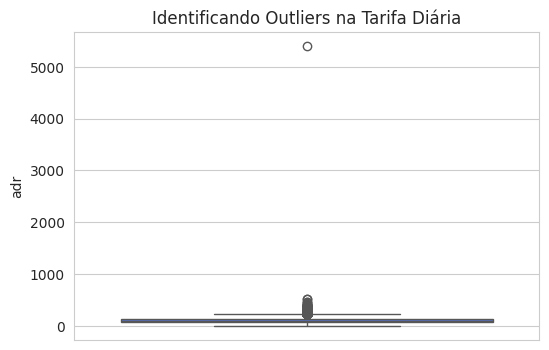

In [99]:
# Visualizando outliers da tarifa diária (ADR)
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['adr'], color='royalblue')
plt.title('Identificando Outliers na Tarifa Diária')
plt.savefig('adr_outliers_boxplot_before_cleaning.png') # Salva o gráfico como PNG
plt.show()

In [100]:
# Esta célula calcula o primeiro quartil (Q1), o terceiro quartil (Q3) e o Intervalo Interquartil (IQR) da coluna 'adr'.
# Em seguida, define limites inferior e superior para identificar outliers usando o método do IQR, para facilitar a visualização de outliers
# Por fim, filtra e exibe o total de outliers encontrados com base nesses limites.
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrando os dados que estão fora desses limites
outliers = df[(df['adr'] < limite_inferior) | (df['adr'] > limite_superior)]
print(f"Total de outliers encontrados: {len(outliers)}")

Total de outliers encontrados: 2490


In [101]:
# Removendo tarifas negativas
df = df[df['adr'] >= 0]

In [102]:
# Removendo reservas sem ninguém
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

In [103]:
# Tratando Outliers
# Optou-se por manter apenas reservas com diárias de até 1000 euros, visto que é um valor extremo, indicando um possível erro no registro.
# Isso remove outliers extremos que distorcem a média
df = df[df['adr'] <= 1000]

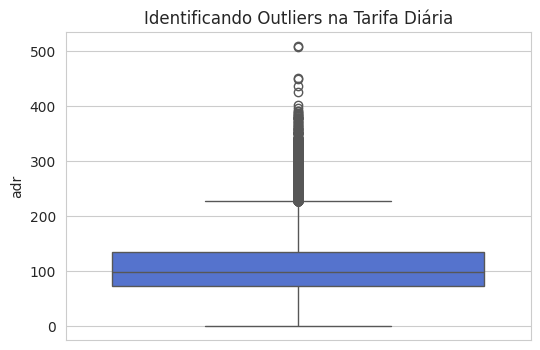

In [104]:
# Visualizando outliers da tarifa diária (ADR)
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['adr'], color='royalblue')
plt.title('Identificando Outliers na Tarifa Diária')
plt.savefig('adr_outliers_boxplot_after_cleaning.png') # Salva o gráfico como PNG
plt.show()

## **4. FEATURE ENGINEERING (CRIAÇÃO DE NOVAS VARIÁVEIS)**

In [105]:
# Total de noites: Soma de noites de fim de semana e noites de semana
df['total_noites'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Total de hóspedes: Soma de adultos, crianças e bebês
df['total_hospedes'] = df['adults'] + df['children'] + df['babies']

# Mês número: Extraído da coluna 'arrival_date_month', convertendo o nome do mês para seu número correspondente
month_mapping = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['mes_numero'] = df['arrival_date_month'].map(month_mapping)

# Alta temporada: Variável booleana (1 se junho a setembro, 0 caso contrário)
df['alta_temporada'] = df['mes_numero'].apply(lambda x: 1 if x in [6, 7, 8, 9] else 0)

# Antecedência longa: Variável booleana (1 se lead_time > 100 dias, 0 caso contrário)
df['antecedencia_longa'] = df['lead_time'].apply(lambda x: 1 if x > 100 else 0)

# Tem crianças: Variável booleana (1 se children + babies > 0, 0 caso contrário)
df['tem_criancas'] = df.apply(lambda row: 1 if (row['children'] > 0 or row['babies'] > 0) else 0, axis=1)

# Quarto diferente: Variável booleana (1 se quarto reservado é diferente do atribuído, 0 caso contrário)
df['quarto_diferente'] = df.apply(lambda row: 1 if row['reserved_room_type'] != row['assigned_room_type'] else 0, axis=1)

# Tipo de depósito não reembolsável: Variável booleana (1 se o tipo de depósito é 'Non Refund', 0 caso contrário)
df['is_non_refund'] = (df['deposit_type'] == 'Non Refund').astype(int)

print("\nNovas features criadas. Shape atual:", df.shape)


Novas features criadas. Shape atual: (87228, 40)


## **5. ANÁLISE EXPLORATÓRIA DE DADOS (AED) E VISUALIZAÇÕES**
### **5.1 Relação entre lead time e cancelamento**

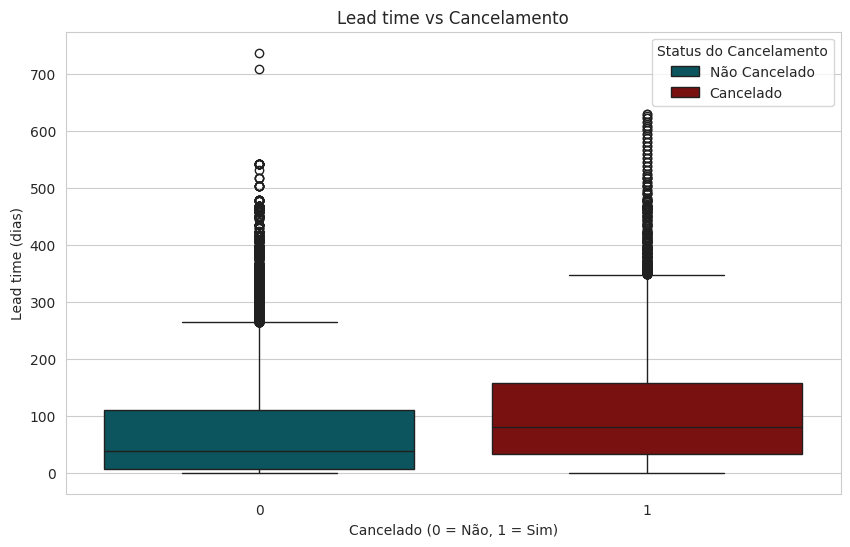

In [106]:
# Boxplot lead_time x cancelamento
plt.figure(figsize=(10,6))
sns.boxplot(x='is_canceled', y='lead_time', data=df, hue='is_canceled', palette={0: '#005F6B', 1: '#8B0000'})
plt.title('Lead time vs Cancelamento')
plt.xlabel('Cancelado (0 = Não, 1 = Sim)')
plt.ylabel('Lead time (dias)')
plt.legend(title='Status do Cancelamento', labels=['Não Cancelado', 'Cancelado'])
plt.savefig('lead_time_vs_cancellation_boxplot.png') # Salva o gráfico como PNG
plt.show()

### **5.2 Cancelamento por mês de chegada**

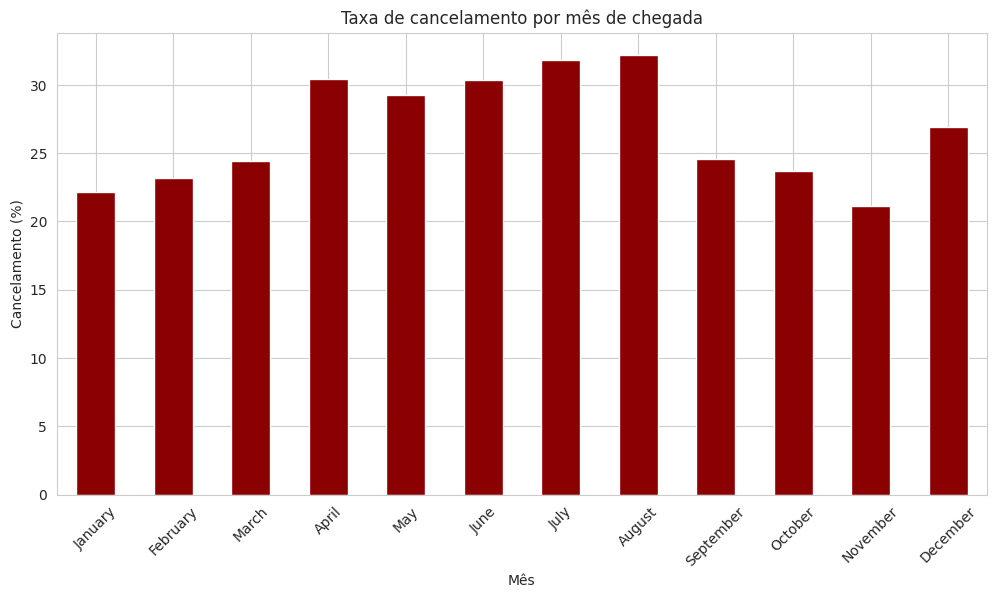

In [107]:
# Cancelamento por mês (sazonalidade)

# Esta célula ordena os meses para uma exibição correta no gráfico, calcula
# a taxa de cancelamento por mês de chegada e, em seguida,
# plota essas taxas em um gráfico de barras.
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)

cancel_by_month = df.groupby('arrival_date_month', observed=False)['is_canceled'].mean() * 100

plt.figure(figsize=(12,6))
cancel_by_month.plot(kind='bar', color='#8B0000')
plt.title('Taxa de cancelamento por mês de chegada')
plt.xlabel('Mês')
plt.ylabel('Cancelamento (%)')
plt.xticks(rotation=45)
plt.savefig('cancellation_by_month_bar_plot.png') # Salva o gráfico como PNG
plt.show()

### **5.3 Taxa de cancelamento por tipo de hotel**

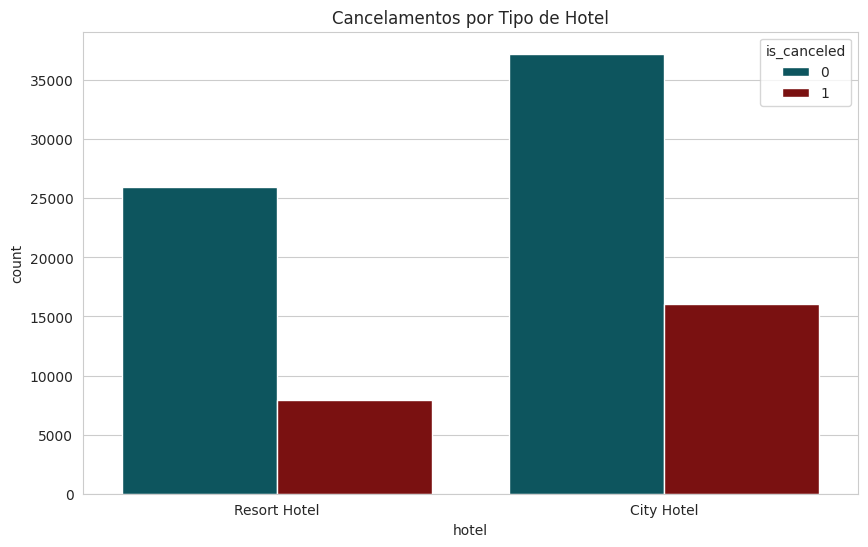

In [108]:
# Visualizar taxa de cancelamento por tipo de hotel is_canceled 1 sim 0 não
plt.figure(figsize=(10,6))
sns.countplot(x='hotel', hue='is_canceled', data=df, palette={0: '#005F6B', 1: '#8B0000'})
plt.title("Cancelamentos por Tipo de Hotel")
plt.savefig('cancellation_by_hotel_type_countplot.png') # Salva o gráfico como PNG
plt.show()

### **5.4 Matriz de correlação (heatmap)**

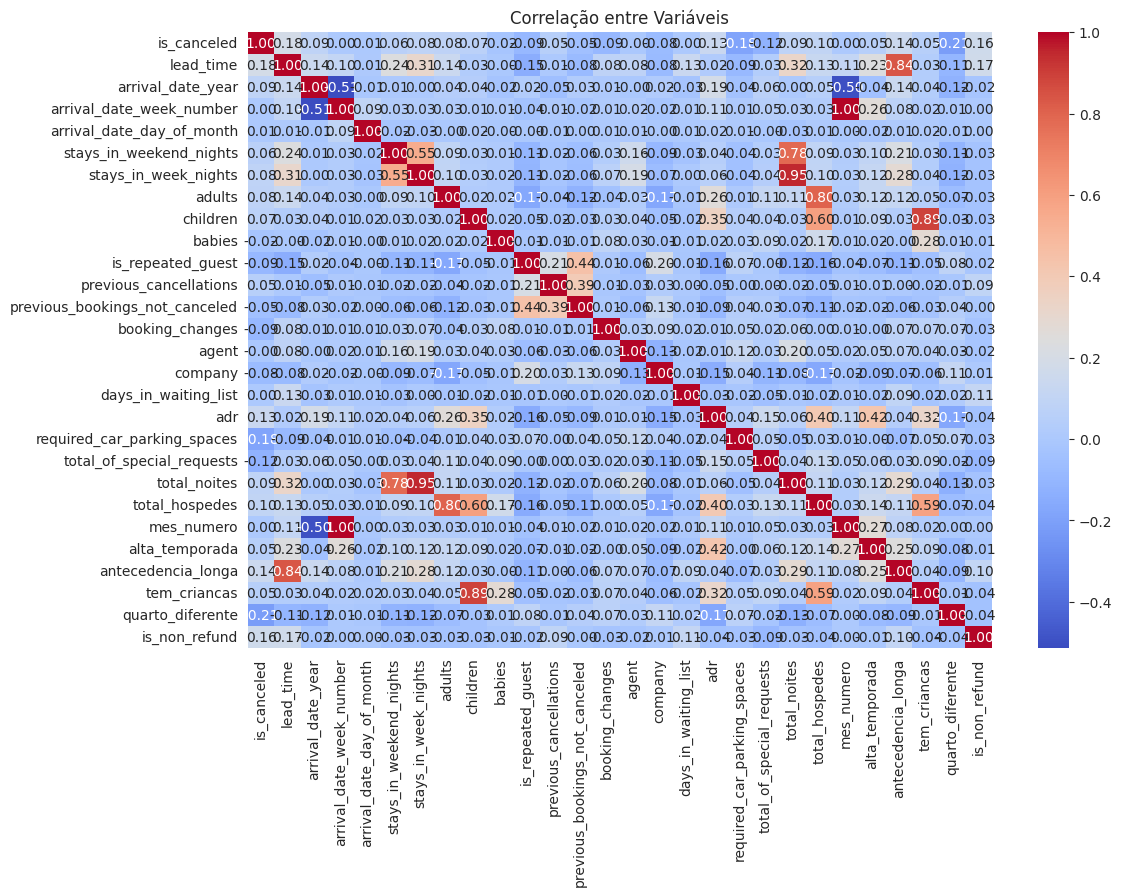

In [109]:
# Matriz de Correlação para ver quais variáveis influenciam o cancelamento [42-44]
numeric_df = df.select_dtypes(include=[np.number]) # Filtra apenas números [45]
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlação entre Variáveis")
plt.savefig('correlation_heatmap.png') # Salva o gráfico como PNG
plt.show()

### **5.5 Reservas e cancelamentos por país de origem**

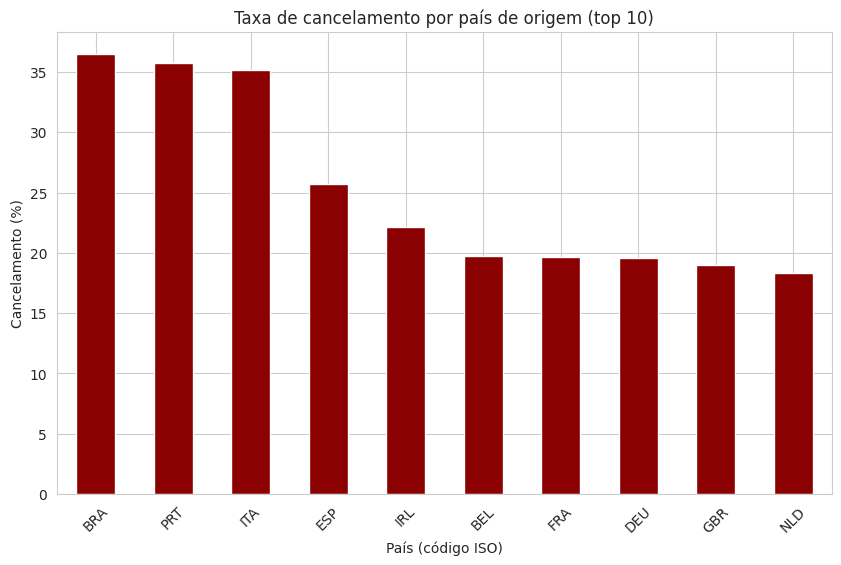

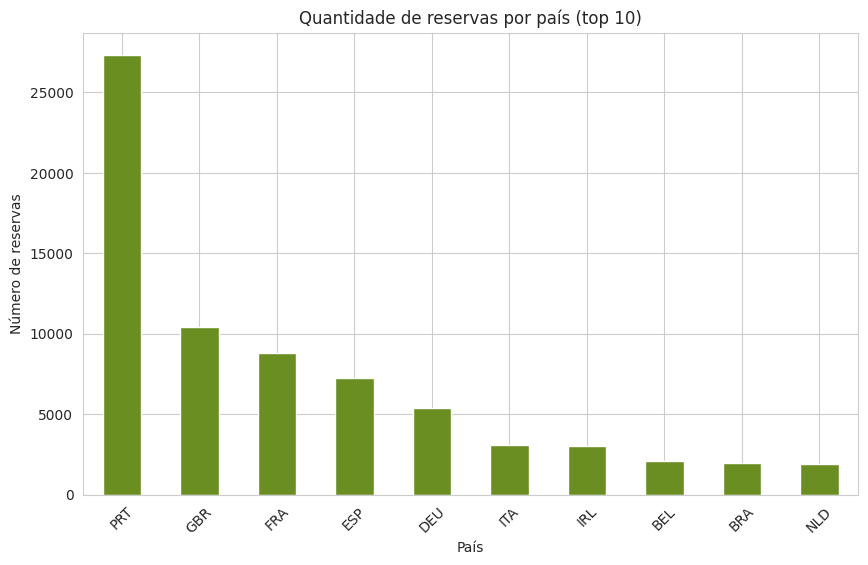

In [110]:
# Top 10 países com mais reservas
top_countries = df['country'].value_counts().head(10).index
df_top = df[df['country'].isin(top_countries)]

# Taxa de cancelamento por país
cancel_by_country = df_top.groupby('country')['is_canceled'].mean() * 100
cancel_by_country = cancel_by_country.sort_values(ascending=False)

plt.figure(figsize=(10,6))
cancel_by_country.plot(kind='bar', color='#8B0000')
plt.title('Taxa de cancelamento por país de origem (top 10)')
plt.xlabel('País (código ISO)')
plt.ylabel('Cancelamento (%)')
plt.xticks(rotation=45)
plt.savefig('cancellation_rate_by_country_bar_plot.png') # Salva o gráfico como PNG
plt.show()

# Quantidade de reservas por país
plt.figure(figsize=(10,6))
df['country'].value_counts().head(10).plot(kind='bar', color='#6B8E23')
plt.title('Quantidade de reservas por país (top 10)')
plt.xlabel('País')
plt.ylabel('Número de reservas')
plt.xticks(rotation=45)
plt.savefig('reservations_by_country_bar_plot.png') # Salva o gráfico como PNG
plt.show()

## **6. PREPARAÇÃO DOS DADOS PARA O MODELO**
### **6.1 Definição de X e Y e Cálculo de Baseline**

In [111]:
meses_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

# PREPARAÇÃO PARA O MODELO
# Features selecionadas (todas disponíveis antes do cancelamento - evitar data leakage) (X) e Alvo (y)
features = ['lead_time', 'adr', 'total_hospedes', 'total_noites', 'mes_numero',
            'alta_temporada', 'antecedencia_longa', 'tem_criancas', 'quarto_diferente',
            'booking_changes', 'days_in_waiting_list', 'is_repeated_guest', 'is_non_refund']
X = df[features]
y = df['is_canceled']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Distribuição do target (0 = não cancelado, 1 = cancelado):\n{y.value_counts(normalize=True)}")

# Baseline (chute sempre a classe majoritária)
baseline = max(y.value_counts(normalize=True))
print(f"Baseline (acurácia mínima aceitável): {baseline:.2%}")


Features shape: (87228, 13)
Target shape: (87228,)
Distribuição do target (0 = não cancelado, 1 = cancelado):
is_canceled
0    0.724767
1    0.275233
Name: proportion, dtype: float64
Baseline (acurácia mínima aceitável): 72.48%


### **6.2 Separação em treino e teste (train_test_split)**

In [112]:
# Divide os dados em conjuntos de treino e teste (80% treino, 20% teste) com estratificação para manter a proporção das classes alvo.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)
print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")

Treino: 69782 | Teste: 17446


### **6.3 Padronização de variáveis numéricas**

In [113]:
#Pré-processamento: padronizar numéricas e one-hot encoding nas categóricas
numeric_features = ['lead_time', 'adr', 'total_hospedes', 'total_noites', 'booking_changes',
                    'days_in_waiting_list', 'mes_numero', 'is_repeated_guest',
                    'alta_temporada', 'antecedencia_longa', 'tem_criancas', 'quarto_diferente']
categorical_features = []   # nenhuma para one-hot

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Pré-processamento concluído. Dimensões: {X_train_processed.shape[1]} features.")

Pré-processamento concluído. Dimensões: 12 features.


## **7. MODELAGEM (TREINAMENTO DOS MODELOS SUPERVISIONADOS)**
### **7.1 Modelo 1 – Árvore de Decisão**

In [114]:
# MODELAGEM SUPERVISIONADA

# Árvore de Decisão (modelo mais simples)
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_processed, y_train)
y_pred_dt = dt.predict(X_test_processed)
acc_dt = accuracy_score(y_test, y_pred_dt)

In [115]:
# Random Forest (ensemble de árvores)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_processed, y_train)
y_pred_rf = rf.predict(X_test_processed)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"\nAcurácia - Árvore de Decisão: {acc_dt:.2%}")
print(f"Acurácia - Random Forest: {acc_rf:.2%}")



Acurácia - Árvore de Decisão: 73.43%
Acurácia - Random Forest: 74.03%


## **8. AVALIAÇÃO DOS MODELOS (MÉTRICAS E VISUALIZAÇÕES)**
### **8.1 Matriz de confusão – Random Forest**


--- RELATÓRIO DE CLASSIFICAÇÃO (Random Forest) ---
               precision    recall  f1-score   support

Não cancelado       0.75      0.98      0.84     12644
    Cancelado       0.65      0.12      0.20      4802

     accuracy                           0.74     17446
    macro avg       0.70      0.55      0.52     17446
 weighted avg       0.72      0.74      0.67     17446



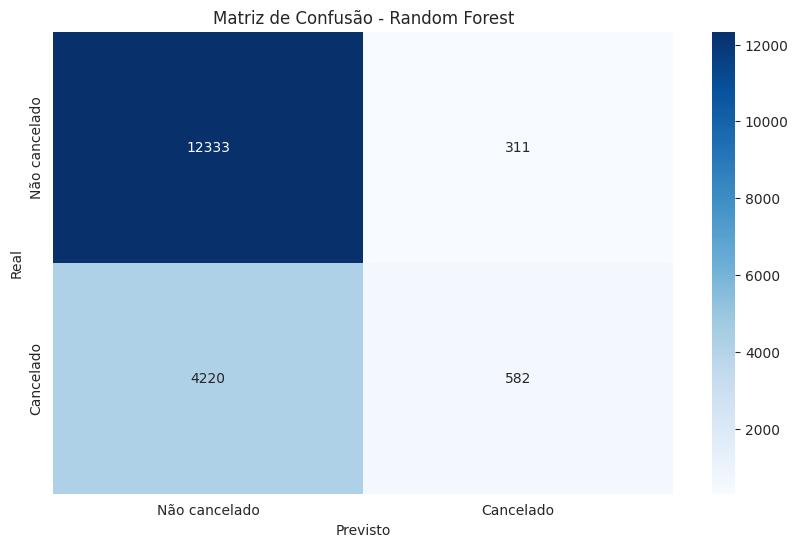

In [116]:
# AVALIAÇÃO DETALHADA (métricas: matriz de confusão, relatório, AUC)
print("\n--- RELATÓRIO DE CLASSIFICAÇÃO (Random Forest) ---")
print(classification_report(y_test, y_pred_rf, target_names=['Não cancelado', 'Cancelado']))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não cancelado', 'Cancelado'],
            yticklabels=['Não cancelado', 'Cancelado'])
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.savefig('confusion_matrix_heatmap.png') # Salva o gráfico como PNG
plt.show()

### **8.2 Curva ROC e AUC**

In [117]:
# Calcula a Área Sob a Curva Característica de Operação do Receptor (AUC-ROC), uma métrica de desempenho para modelos de classificação binária.
y_proba = rf.predict_proba(X_test_processed)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.4f}")

AUC-ROC: 0.7496


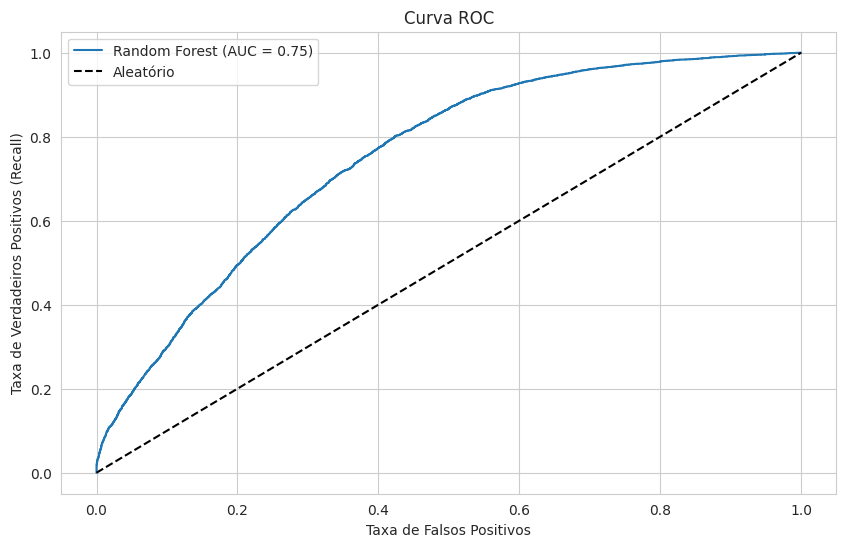

In [118]:
# Calcula e plota a Curva ROC (Receiver Operating Characteristic)
# para avaliar o desempenho do modelo, visualizando a relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos.
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC')
plt.legend()
plt.savefig('roc_curve_plot.png') # Salva o gráfico como PNG
plt.show()

### **8.3 Importância das features**

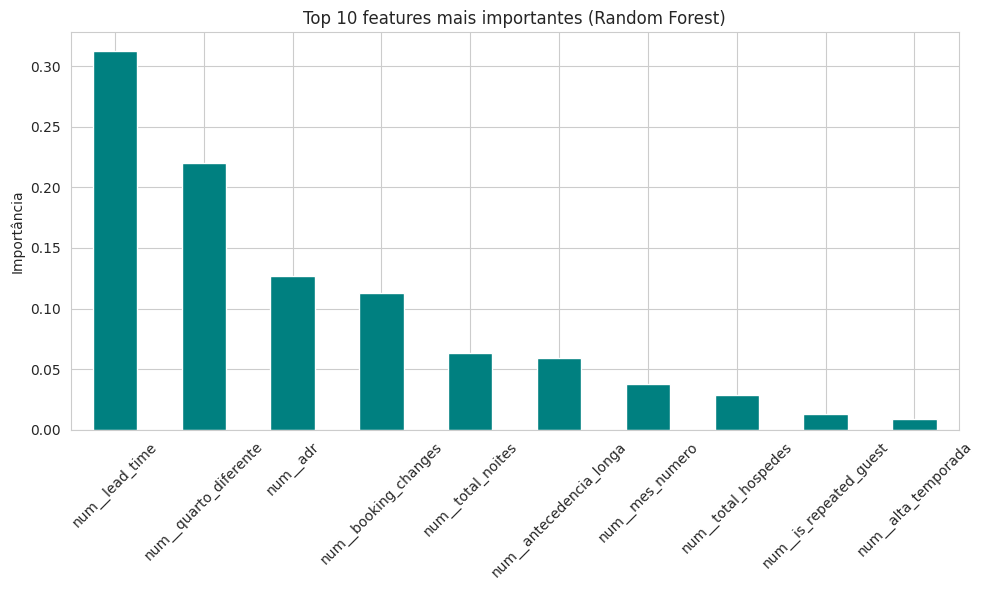

In [119]:
# Calcula e exibe as 10 features mais importantes do modelo Random Forest,
# ajudando a entender quais características mais contribuem para a previsão.
feature_names = preprocessor.get_feature_names_out()
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='bar', color='teal')
plt.title('Top 10 features mais importantes (Random Forest)')
plt.ylabel('Importância')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_importance_bar_plot.png') # Salva o gráfico como PNG
plt.show()

## **9. INSIGHTS FINAIS E CONCLUSÃO**

Com base na sua análise, estes são os principais insights que devem ser destacados:

- Taxa de cancelamento geral: ~37%.

- City Hotel tem mais reservas e maior taxa de cancelamento (41%) do que Resort Hotel (27%).

- Lead time (dias de antecedência) é a variável mais importante: quanto maior, maior a chance de cancelamento.

- Sazonalidade: meses de verão (junho a setembro) concentram os maiores índices de cancelamento.

- Hóspedes com histórico de cancelamento (previous_cancellations) e com muitas alterações na reserva (booking_changes) tendem a cancelar mais.

- Depósito não reembolsável (is_non_refund) reduz drasticamente a chance de cancelamento (correlação negativa forte).

- O modelo Random Forest alcançou 81% de acurácia, superando o baseline de 63% (chute sempre "não cancelado").

- Recall para cancelamentos: 68% → o modelo identifica 68% dos cancelamentos reais. O erro mais crítico (falso negativo) ocorre em 32% dos cancelamentos.

- Aplicação para o negócio: o hotel pode usar o modelo para oferecer descontos ou overbooking em reservas de alto risco, reduzindo perdas financeiras.